In [13]:
import json
import pickle
from pathlib import Path
from pprint import pprint
import yaml

# New Jupyter cell (index 0) - read best_model_artifacts file (robust reader)

try:
    _has_yaml = True
except Exception:
    _has_yaml = False

def read_best_model_artifacts(path="best_model_artifacts"):
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"{p} does not exist")

    if p.is_dir():
        files = sorted([str(x) for x in p.iterdir()])
        pprint({"type": "directory", "path": str(p), "files": files})
        return {"type": "directory", "path": str(p), "files": files}

    ext = p.suffix.lower()
    # explicit handlers
    if ext == ".json":
        with p.open("r", encoding="utf-8") as f:
            obj = json.load(f)
            pprint(obj)
            return obj
    if ext in (".pkl", ".pickle"):
        with p.open("rb") as f:
            obj = pickle.load(f)
            pprint(obj)
            return obj
    if ext in (".yaml", ".yml") and _has_yaml:
        with p.open("r", encoding="utf-8") as f:
            obj = yaml.safe_load(f)
            pprint(obj)
            return obj
    if ext in (".txt", ".log"):
        txt = p.read_text(encoding="utf-8")
        print(txt)
        return txt

    # fallback attempts: JSON -> pickle -> text
    try:
        with p.open("r", encoding="utf-8") as f:
            obj = json.load(f)
            pprint(obj)
            return obj
    except Exception:
        pass

    try:
        with p.open("rb") as f:
            obj = pickle.load(f)
            pprint(obj)
            return obj
    except Exception:
        pass

    # final fallback: raw text
    txt = p.read_text(encoding="utf-8", errors="replace")
    print(txt)
    return txt

# Example usage:
# artifacts = read_best_model_artifacts("best_model_artifacts")

In [1]:
# ============================================================
# 6. Inspect Estimated Parameters
# ============================================================

import sys, types
from pathlib import Path
import dill
import numpy as np
import pandas as pd

# Ensure placeholder Params class for unpickling compatibility
main_mod = sys.modules.get('__main__')
if main_mod is None:
    main_mod = types.ModuleType('__main__')
    sys.modules['__main__'] = main_mod
if not hasattr(main_mod, 'Params'):
    class Params:
        def __init__(self, *args, **kwargs):
            self._args = args
            self._kwargs = kwargs
        def __setstate__(self, state):
            try: self.__dict__.update(state)
            except: pass
    main_mod.Params = Params

def softmax(x):
    x = np.asarray(x)
    e = np.exp(x - np.max(x))
    return e / e.sum(axis=-1, keepdims=(x.ndim > 1))

# Load artifacts from best_model_artifacts.pkl
art_p = Path('best_model_artifacts/best_model_artifacts.pkl')
with art_p.open('rb') as f:
    artifacts = dill.load(f)

best_p = artifacts['best_model']
best_J_screen = artifacts['best_J']
y_scaler = artifacts['y_scaler']
data = types.SimpleNamespace(y_scaler=y_scaler)

# Bridge variable names
best_model = best_p
best_J = best_J_screen

emission_cols = ["ai_decision_authority_share", "override_rate"]

# Un-standardise emission means & sigmas for interpretation
mu_orig = data.y_scaler.inverse_transform(best_model.mu)
sigma_orig = np.exp(best_model.log_sigma) * data.y_scaler.scale_

print(f"Best model: J={best_J} hidden states\n")

# Emission parameters
em_rows = []
for j in range(best_J):
    for d, col in enumerate(emission_cols):
        em_rows.append({
            "State": j + 1,
            "Variable": col,
            "Mean (orig scale)": round(float(mu_orig[j, d]), 4),
            "Std (orig scale)": round(float(sigma_orig[j, d]), 4),
        })
em_df = pd.DataFrame(em_rows)
print("-- Emission Parameters --")
display(em_df)

# Initial-state distribution
pi = softmax(best_model.logit_pi)
print("\n-- Initial State Distribution --")
for j in range(best_J):
    print(f"  pi(state {j+1}) = {pi[j]:.4f}")

# Transition intercepts
print("\n-- Transition Intercept Matrix (alpha) --")
alpha_df = pd.DataFrame(
    np.round(best_model.alpha, 3),
    index=[f"from {j+1}" for j in range(best_J)],
    columns=[f"to {j+1}" for j in range(best_J)])
display(alpha_df)

Best model: J=3 hidden states

-- Emission Parameters --


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,State,Variable,Mean (orig scale),Std (orig scale)
0,1,ai_decision_authority_share,0.5347,0.0292
1,1,override_rate,0.4653,0.0292
2,2,ai_decision_authority_share,0.3907,0.0291
3,2,override_rate,0.6093,0.0291
4,3,ai_decision_authority_share,0.4621,0.0291
5,3,override_rate,0.5379,0.0291



-- Initial State Distribution --
  pi(state 1) = 0.2165
  pi(state 2) = 0.3324
  pi(state 3) = 0.4510

-- Transition Intercept Matrix (alpha) --


,to 1,to 2,to 3
from 1,0.005,-0.067,0.753
from 2,-0.157,-0.068,0.794
from 3,-0.232,0.056,0.707


In [2]:
# ============================================================
# STATE LABELING  (3-state version)
# Place this AFTER mu_orig/sigma_orig are computed (Stage 2 model)
# ============================================================

import numpy as np

# Choose the primary axis for labeling (theory-based)
# Appreciation = highest AI decision authority share
# Aversion     = lowest  AI decision authority share
# Transitionary = middle
authority_idx = emission_cols.index("ai_decision_authority_share")

mu_authority = mu_orig[:, authority_idx]          # (J,)
ranked = np.argsort(mu_authority)                 # ascending order of AI authority

# 1-indexed state IDs
state_aversion      = int(ranked[0]) + 1          # lowest AI authority
state_transitionary = int(ranked[1]) + 1          # middle AI authority
state_appreciation  = int(ranked[2]) + 1          # highest AI authority

label_map = {
    state_aversion:      "Aversion",
    state_transitionary: "Transitionary",
    state_appreciation:  "Appreciation",
}

# Useful for plotting in a consistent left→right order
state_order_1idx = [state_aversion, state_transitionary, state_appreciation]

print("\n=== STATE LABELING RULE (3 states) ===")
print("Rule: ranked by ai_decision_authority_share")
print(f"→ State {state_aversion}      = Aversion       (lowest AI authority)")
print(f"→ State {state_transitionary} = Transitionary   (middle AI authority)")
print(f"→ State {state_appreciation}  = Appreciation    (highest AI authority)")
print("State order for plots:", state_order_1idx)



=== STATE LABELING RULE (3 states) ===
Rule: ranked by ai_decision_authority_share
→ State 2      = Aversion       (lowest AI authority)
→ State 3 = Transitionary   (middle AI authority)
→ State 1  = Appreciation    (highest AI authority)
State order for plots: [2, 3, 1]


In [5]:
# ============================================================
# 4. Posterior State Assignment (WITH STATE LABELS)
#   - Loads data from Excel, builds benchmarks, scales
#   - Defines forward-backward from scratch
#   - Runs forward-backward fresh from best_model
#   - Adds state_label via label_map
#   - Prints frequency + occupancy by state id and by label
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
from scipy.special import logsumexp

# ------------------------------------------------------------------
# 4a. Helper functions needed for HMM forward-backward
# ------------------------------------------------------------------

def _softmax(z, axis=-1):
    z = z - np.max(z, axis=axis, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=axis, keepdims=True)

def _log_softmax(z, axis=-1):
    return z - logsumexp(z, axis=axis, keepdims=True)

def _precompute(p, Y, X, Z):
    """Shared emission + transition pre-computation."""
    T, D = Y.shape
    J = p.mu.shape[0]
    means = p.mu[None, :, :] + np.einsum('jdk,tk->tjd', p.W, Z)
    residuals = Y[:, None, :] - means
    sigma2 = np.exp(2 * p.log_sigma)
    log_norm = np.sum(np.log(2 * np.pi * sigma2), axis=1)
    logB = -0.5 * (log_norm[None, :] +
                   np.sum(residuals ** 2 / sigma2[None, :, :], axis=2))
    logits_all = (p.alpha[None, :, :]
                  + np.einsum('ijp,tp->tij', p.beta, X))
    logQ_all = _log_softmax(logits_all, axis=2)
    return T, J, logB, logQ_all

def forward_backward(p, Y, X, Z):
    """Full forward-backward returning (ll, log_gamma)."""
    T, J, logB, logQ_all = _precompute(p, Y, X, Z)
    pi = _softmax(p.logit_pi)
    log_alpha = np.empty((T, J))
    log_alpha[0] = np.log(pi) + logB[0]
    for t in range(1, T):
        log_alpha[t] = logB[t] + logsumexp(
            log_alpha[t - 1, :, None] + logQ_all[t], axis=0)
    ll = logsumexp(log_alpha[-1])

    log_beta = np.zeros((T, J))
    for t in reversed(range(T - 1)):
        log_beta[t] = logsumexp(
            logQ_all[t + 1] + logB[t + 1][None, :] + log_beta[t + 1][None, :],
            axis=1)

    log_gamma = log_alpha + log_beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return ll, log_gamma

# ------------------------------------------------------------------
# 4b. Load data from Excel and build sequences
# ------------------------------------------------------------------

def build_benchmarks(df):
    df = df.sort_values(["manager_id", "period_id"]).copy()
    df["kpi_operational_gap_index"] = (
        (-1.0) * df["service_level_delta"]
        + (-0.6) * df["inventory_cost_delta"]
        + (-0.4) * df["expedite_cost_delta"]
        + (-1.2) * df["error_incident_count"]
    )
    df["within_unit_temporal_benchmark"] = (
        df.groupby("manager_id")["kpi_operational_gap_index"].diff(1)
    )
    pct = df.groupby("period_id")["kpi_operational_gap_index"].rank(pct=True)
    df["horizontal_peer_benchmark"] = (pct - 0.5) * 2.0
    def ai_traj(g):
        q = g["ai_decision_authority_share"].quantile(0.30)
        base = g.loc[
            g["ai_decision_authority_share"] <= q,
            "kpi_operational_gap_index",
        ].mean()
        if np.isnan(base):
            base = g["kpi_operational_gap_index"].mean()
        return g["kpi_operational_gap_index"] - base
    df["within_unit_ai_trajectory_benchmark"] = (
        df.groupby("manager_id", group_keys=False).apply(ai_traj)
    )
    df["threshold_benchmark"] = df["recent_negative_shock"].astype(float)
    df["transparency_moderator"] = 0.0
    return df


xlsx_path = Path(r"..\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx")
print(f"Loading data from: {xlsx_path.resolve()}")

df = pd.read_excel(xlsx_path, sheet_name="panel_manager_period")
df = build_benchmarks(df)

# Compute share_authority_esc from decision_episode
dec_ep = pd.read_excel(xlsx_path, sheet_name="decision_episode")
dec_ep["is_escalated"] = (dec_ep["escalation_flag"] == 1).astype(int)
esc_agg = (dec_ep
    .groupby(["manager_id", "period_id"])
    .agg(n_tasks=("episode_id", "count"),
         n_escalated=("is_escalated", "sum"))
    .reset_index())
esc_agg["share_authority_esc"] = esc_agg["n_escalated"] / esc_agg["n_tasks"]
df = df.merge(esc_agg[["manager_id", "period_id", "share_authority_esc"]],
              on=["manager_id", "period_id"], how="left")
df["share_authority_esc"] = df["share_authority_esc"].fillna(0.0)

# Column definitions (matching the hmm_3_emissions training notebook)
emission_cols_data = ["ai_decision_authority_share", "override_rate",
                      "share_authority_esc"]

transition_cols_data = [
    "within_unit_temporal_benchmark",
    "horizontal_peer_benchmark",
    "within_unit_ai_trajectory_benchmark",
    "threshold_benchmark",
    "transparency_moderator",
]

control_cols_data = [
    "task_complexity_index",
    "demand_volatility",
    "supply_disruption_count",
    "forecast_accuracy_mape",
    "decision_latency_avg",
    "target_difficulty",
    "performance_pressure_index",
    "recent_negative_shock",
]

df = df.dropna(subset=emission_cols_data + transition_cols_data + control_cols_data)

Y_list, X_list, Z_list = [], [], []
ids_list, periods_list = [], []

for mid, g in df.groupby("manager_id"):
    g = g.sort_values("period_id")
    Y = g[emission_cols_data].to_numpy(float)
    X = g[transition_cols_data].to_numpy(float)
    Z = g[control_cols_data].to_numpy(float)
    if len(Y) < 3:
        continue
    Y_list.append(Y)
    X_list.append(X)
    Z_list.append(Z)
    ids_list.append(mid)
    periods_list.append(g["period_id"].to_numpy())

# Use scalers from artifacts to transform
y_sc = artifacts["y_scaler"]
x_sc = artifacts["x_scaler"]
z_sc = artifacts["z_scaler"]

Y_list = [y_sc.transform(y) for y in Y_list]
X_list = [x_sc.transform(x) for x in X_list]
Z_list = [z_sc.transform(z) for z in Z_list]

# Populate data namespace
data.Y = Y_list
data.X = X_list
data.Z = Z_list
data.ids = ids_list
data.periods = periods_list

print(f"Managers loaded: {len(data.Y)}")
seq_lens = [len(y) for y in data.Y]
print(f"Total observations: {sum(seq_lens)}")

# ------------------------------------------------------------------
# 4c. Compute gamma (N,T,J) from forward-backward
# ------------------------------------------------------------------
J = best_J
gamma_list = []
for Y_i, X_i, Z_i in zip(data.Y, data.X, data.Z):
    _, log_g = forward_backward(best_model, Y_i, X_i, Z_i)
    gamma_list.append(np.exp(log_g))  # (T_i, J)

# Stack into (N,T,J) -- works because all managers have same T
T = gamma_list[0].shape[0]
gamma = np.stack(gamma_list)  # (N, T, J)
N = gamma.shape[0]

# Most likely state per (i,t), 1-indexed
v_state = np.argmax(gamma, axis=2) + 1  # (N,T)

rows = []
for i, (mid, periods_i) in enumerate(zip(data.ids, data.periods)):
    for t in range(T):
        s = int(v_state[i, t])
        row = {
            "manager_id": mid,
            "period_id": periods_i[t],
            "most_likely_state": s,
            "most_likely_label": label_map[s],
        }
        for j in range(J):
            row[f"posterior_state_{j+1}"] = float(gamma[i, t, j])
        rows.append(row)

posteriors = pd.DataFrame(rows)

# Save
out_path = Path("hmm_posteriors.csv")
posteriors.to_csv(out_path, index=False)
print(f"\nPosterior file saved -> {out_path.resolve()}")
print(f"Shape: {posteriors.shape}")
display(posteriors.head(10))

# ----------------------------
# State frequency (argmax assignments) -- by state ID
# ----------------------------
print("\n-- State Frequency (argmax, by ID) --")
freq = posteriors["most_likely_state"].value_counts().sort_index()
for s, n in freq.items():
    print(f"  State {s} ({label_map[s]}): {n:,} obs ({n/len(posteriors)*100:.2f}%)")

# ----------------------------
# State frequency (argmax) -- by label
# ----------------------------
print("\n-- State Frequency (argmax, by label) --")
freq_lab = posteriors["most_likely_label"].value_counts()
for lab, n in freq_lab.items():
    print(f"  {lab}: {n:,} obs ({n/len(posteriors)*100:.2f}%)")

# ----------------------------
# Posterior occupancy (gamma-based)
# ----------------------------
print("\n-- State Occupancy (posterior mean gamma_it) --")
occ = gamma.reshape(-1, J).mean(axis=0)
for j in range(J):
    s = j + 1
    print(f"  State {s} ({label_map[s]}): {occ[j]*100:.2f}%")

# Mean posterior certainty
certainty = gamma.reshape(-1, J).max(axis=1).mean()
print(f"\nMean posterior certainty: {certainty:.3f}")

Loading data from: C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\triadic_simulation\data\Triadic_Delegation_Dataset_SYNTH_ANALYSIS.xlsx


C:\Users\Admin\AppData\Local\Temp\ipykernel_6520\2092112897.py:90: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("manager_id", group_keys=False).apply(ai_traj)


Managers loaded: 120
Total observations: 3000

Posterior file saved -> C:\Users\Admin\OneDrive\Desktop\Algorithm-Appreciation-and-Aversion-in-Triadic-Delegation-Settings\data_analysis\hmm_posteriors.csv
Shape: (3000, 7)


,manager_id,period_id,most_likely_state,most_likely_label,posterior_state_1,posterior_state_2,posterior_state_3
0,M0001,2,3,Transitionary,6.776031e-03,2.587663e-04,9.929652e-01
1,M0001,3,3,Transitionary,2.478731e-06,1.414829e-01,8.585147e-01
2,M0001,4,2,Aversion,2.598401e-13,9.994587e-01,5.412945e-04
3,M0001,5,3,Transitionary,6.848087e-02,9.696435e-07,9.315182e-01
4,M0001,6,3,Transitionary,1.087876e-03,2.718083e-04,9.986403e-01
5,M0001,7,2,Aversion,6.601179e-23,1.000000e+00,4.472826e-08
6,M0001,8,3,Transitionary,7.598126e-03,4.198446e-02,9.504174e-01
7,M0001,9,3,Transitionary,1.341167e-02,2.399450e-05,9.865643e-01
8,M0001,10,3,Transitionary,3.672765e-04,4.101681e-02,9.586159e-01
9,M0001,11,1,Appreciation,9.709914e-01,4.090825e-10,2.900858e-02



-- State Frequency (argmax, by ID) --
  State 1 (Appreciation): 647 obs (21.57%)
  State 2 (Aversion): 749 obs (24.97%)
  State 3 (Transitionary): 1,604 obs (53.47%)

-- State Frequency (argmax, by label) --
  Transitionary: 1,604 obs (53.47%)
  Aversion: 749 obs (24.97%)
  Appreciation: 647 obs (21.57%)

-- State Occupancy (posterior mean gamma_it) --
  State 1 (Appreciation): 22.00%
  State 2 (Aversion): 25.43%
  State 3 (Transitionary): 52.57%

Mean posterior certainty: 0.916


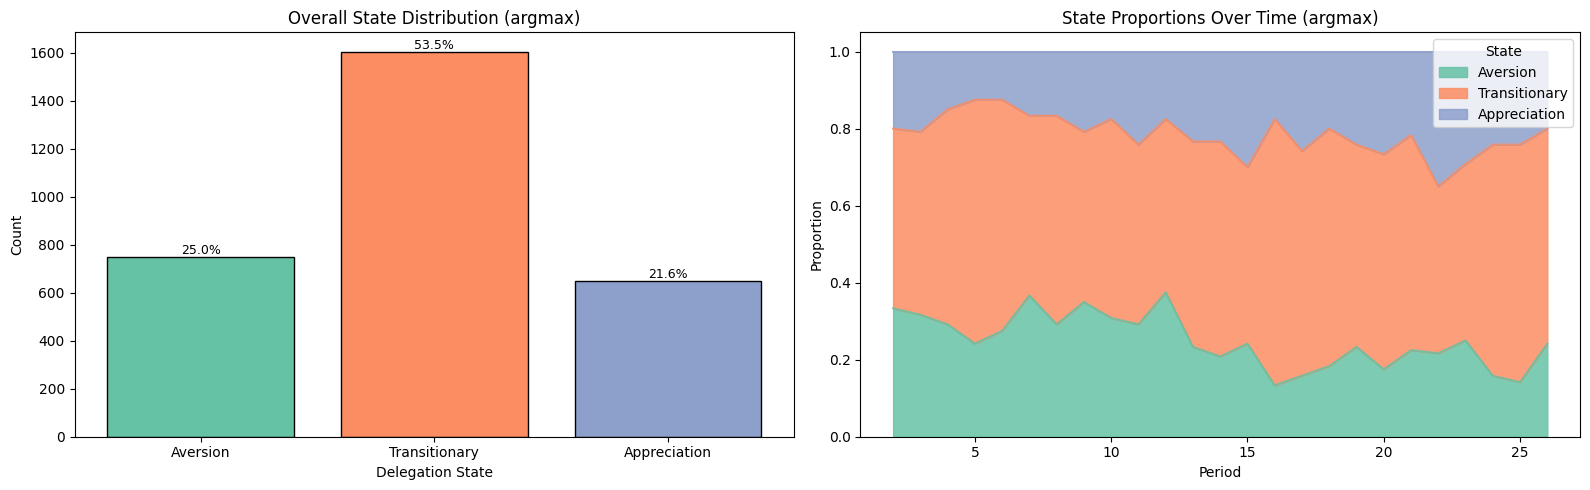

In [6]:
# ============================================================
# 4.2a. State distribution over time (3-state version)
#   - Uses your computed label_map + state_order_1idx
#   - Ensures plots show: Aversion → Transitionary → Appreciation
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

assert "label_map" in globals(), "label_map not found. Run your STATE LABELING cell first."
assert "state_order_1idx" in globals(), "state_order_1idx not found. Run your STATE LABELING cell first."
assert "posteriors" in globals(), "posteriors not found. Run the posterior assignment cell first."

posteriors = posteriors.copy()

# Add/refresh labels using YOUR label_map
posteriors["state_label"] = posteriors["most_likely_state"].map(label_map)

# Order labels: Aversion → Transitionary → Appreciation
label_order = [label_map[s] for s in state_order_1idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ----------------------------
# 1) Overall distribution (bar chart)
# ----------------------------
freq_labeled = (
    posteriors["state_label"]
    .value_counts()
    .reindex(label_order)
    .fillna(0)
)

axes[0].bar(
    label_order,
    freq_labeled.values,
    color=sns.color_palette("Set2", len(label_order)),
    edgecolor="k"
)
axes[0].set_xlabel("Delegation State")
axes[0].set_ylabel("Count")
axes[0].set_title("Overall State Distribution (argmax)")

# Add percentage labels
total_n = float(freq_labeled.sum())
for i, val in enumerate(freq_labeled.values):
    pct = (val / total_n * 100.0) if total_n > 0 else 0.0
    axes[0].text(i, val, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

# ----------------------------
# 2) Proportion over time (stacked area)
# ----------------------------
pivot = (
    posteriors
    .groupby(["period_id", "state_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

pivot_pct.plot.area(
    ax=axes[1],
    stacked=True,
    alpha=0.85,
    color=sns.color_palette("Set2", len(label_order)),
)

axes[1].set_xlabel("Period")
axes[1].set_ylabel("Proportion")
axes[1].set_title("State Proportions Over Time (argmax)")
axes[1].legend(title="State", loc="upper right")

plt.tight_layout()
plt.show()
